<a href="https://colab.research.google.com/github/simichakravarty16/ds2002-fa26/blob/main/notebooks/03-pandas-cleaning/2026-09-21%20%E2%80%94%20Data%20Cleaning%20(types%2C%20missing%2C%20duplicates)%20%E2%80%94%20Lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS2002 · Data Cleaning (types, missing, duplicates)

**Lecture — 2026-09-21 · Fall 2026**  
**Class time:** 45 minutes
**Name:** Simi Chakravarty
---

## What today is about

By the end of class you should be able to take a file you have never seen, work out what is wrong with it, fix it, and save the result so you never have to fix it again.

The plan:

1. **Inspect.** Pull a real file off the internet and run the six commands that tell you what you are holding.
2. **Repair.** Learn the five fixes that handle almost every messy file, in the order that works, on eight rows you can check by hand.
3. **Finish and save.** Run those fixes on the real file and write the clean copy to your Google Drive.

### Why this gets a whole class

**A file is somebody's record of something. It is not the thing itself.**

A sales file is not sales. It is what a cash register wrote down about sales. Registers get restarted, cashiers scan an item twice, two stores spell the same department differently, and a software update changes the date format halfway through the year. Cleaning is the work of closing the gap between what happened and what got recorded.

**Bad data does not announce itself.**

A syntax error stops your program and tells you the line number. Bad data does none of that. It runs through every calculation and comes out the far end looking like an answer. You will watch that happen in about ten minutes, when we ask this file a simple money question and get a confident, completely wrong reply with no warning of any kind. That is why checking has to be a routine you always run, not something you do when you already suspect a problem.

**There are only about five things that go wrong.**

People have been cleaning data long enough to name the categories, and almost every problem you meet is one of these:

| Problem | What it looks like |
|---|---|
| **Completeness** | Values that are missing |
| **Validity** | Values in the wrong form — a number stored as text, a date stored as `09/05/2026` |
| **Consistency** | One thing written several ways — `Food`, `food`, `FOOD` |
| **Uniqueness** | The same record stored more than once |
| **Accuracy** | Values that are simply wrong — a quantity of `-3`, a price of `$0` |

Today covers the first four. Accuracy is the hard one, because spotting it usually means knowing something about the business that the file cannot tell you.

**Cleaning is a series of decisions, and the decisions have to be written down.**

This is the part people skip. Most cleaning steps are not obviously right. If a quantity is missing, do you drop the row, fill it with zero, or fill it with the average? Every choice changes your final number and every one of them is the correct call in some situation. Two careful people can clean the same file differently and both be right.

So the thing that separates good work from bad work is not the answer. It is whether you can say what you did and how many rows it touched. "Revenue was $34,177" is weak. "Revenue was $34,177 after dropping 59 duplicate rows, which moved the total by $323" is something a person can check, question, or disagree with.

**Do it in code, not by hand.**

You could open the file in a spreadsheet and fix it manually. Do not. A script can be re-run when next month's file arrives, read by somebody checking your work, and corrected in one place when you get a step wrong. Hand edits leave no record of what you changed, and you will not remember.

Pandas is what makes this quick. Lowercasing one value and lowercasing 4,622 of them are the same keystroke.

---

## Part 1 — Opening a file nobody cleaned for you

From here on, the data you work with comes from somebody else. They picked the column names. They typed the values. They did not write you a manual and they did not check their work.

So before you answer any question, you have to find out what you are holding. There is a routine for that. It is about six commands, it takes two minutes, and running it in the same order every time is what keeps you from losing an hour to a bug that turns out to be a typo in row 900.

We will run it on a real file: **4,622 rows of Chipotle orders** that an instructor posted to GitHub years ago. Nobody tidied it up for this class.

In [ ]:
import pandas as pd

URL = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

# This one is tab-separated, so sep='\t'. Leave that off and every line
# arrives as a single column.
orders = pd.read_csv(URL, sep='\t')

print(f'{len(orders):,} rows, {len(orders.columns)} columns')
orders.head()

4,622 rows, 5 columns


,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


Two things in that cell are worth naming.

**`read_csv` took a web address.** You did not download anything and the file never landed on your computer. Pandas fetched it and handed back a table you can query. A local file path works the same way, so code you write against one works against the other.

**Notice `sep='\t'`.** This file ends in `.tsv`, which means tab-separated instead of comma-separated. Leave that argument out and pandas reads each line as one long column. When a file loads but looks wrong, check the separator first.

### Step 1 — `.info()`

Run this on every new table, before anything else.

In [ ]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            4622 non-null   int64
 1   quantity            4622 non-null   int64
 2   item_name           4622 non-null   str  
 3   choice_description  3376 non-null   str  
 4   item_price          4622 non-null   str  
dtypes: int64(2), str(3)
memory usage: 180.7 KB


Here is what it just told you.

**`RangeIndex: 4622 entries`** — 4,622 rows, numbered 0 through 4621.

**Non-Null Count** — how many rows actually have a value. Four columns say `4622 non-null`, so they are complete. `choice_description` says `3376`, which means 1,246 rows are blank there. You now know where the holes are before you trip over one.

**Dtype** — what pandas decided the column holds. `int64` is whole numbers, `float64` is decimals, and `str` (older versions print `object`) is text.

Read the Dtype column first, every single time. `item_price` is money, and pandas is calling it text. That is the most useful thing on the screen, and we come back to it in a few minutes.

### Step 2 — `.describe()`

Summary statistics, so you can see the shape of the numbers.

In [ ]:
orders.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


Two things to take from that.

`quantity` is almost all 1s, with a maximum of 15, so a few people bought in bulk. `order_id` gets summarized too, and its average is meaningless. Pandas cannot tell an ID number from a measurement. You have to.

More useful is what is **not** there. `item_price` is missing from the output entirely, because `.describe()` only reports on numeric columns. A money column that fails to show up is a money column pandas does not think is a number. The absence is the finding.

### Step 3 — count what is in the columns

`.nunique()` gives you how many different values a column has. `.value_counts()` gives you what they are and how often each shows up.

In [ ]:
print('distinct menu items:', orders['item_name'].nunique())
print('separate orders    :', orders['order_id'].nunique(), 'across', len(orders), 'rows')
print()
print(orders['item_name'].value_counts().head(10))

distinct menu items: 50
separate orders    : 1834 across 4622 rows

item_name
Chicken Bowl                    726
Chicken Burrito                 553
Chips and Guacamole             479
Steak Burrito                   368
Canned Soft Drink               301
Chips                           211
Steak Bowl                      211
Bottled Water                   162
Chicken Soft Tacos              115
Chips and Fresh Tomato Salsa    110
Name: count, dtype: int64


Fifty items on the menu, and Chicken Bowl appears 726 times.

Now look at the second line. There are 1,834 separate orders spread across 4,622 rows. One order can be a burrito, chips, and a drink, so each row is a line item and `order_id` repeats on purpose. Learning that now stops you from "fixing" it later.

### Step 4 — find the holes

In [ ]:
print(orders.isna().sum())

order_id                 0
quantity                 0
item_name                0
choice_description    1246
item_price               0
dtype: int64


1,246 blanks in `choice_description`, and nothing missing anywhere else.

Do not reach for `fillna` yet. Ask what the blank means first.

In [ ]:
# Before filling or dropping anything: which items have no choices to make?
print(orders[orders['choice_description'].isna()]['item_name'].value_counts().head())

item_name
Chips and Guacamole             479
Chips                           211
Bottled Water                   162
Chips and Fresh Tomato Salsa    110
Side of Chips                   101
Name: count, dtype: int64


The blanks are Chips, Bottled Water, Chips and Guacamole, Side of Chips. Those items have nothing to choose. There is no salsa decision on a bottle of water.

So the blank is not damage. It means *does not apply*, which is a perfectly good thing for a cell to say. Fill it with `'none'` and you have invented a topping. Drop those rows and you have deleted 1,246 real sales, including the single most-ordered item in the file.

**Missing data is a question before it is a problem.** Answer the question, then decide.

### Step 5 — check for repeats

Two different questions hide under the word "duplicate," and they have different answers.

In [ ]:
print('rows identical in every column:', orders.duplicated().sum())
print('rows sharing an order_id      :', orders['order_id'].duplicated().sum())
print()
orders[orders.duplicated(keep=False)].sort_values('order_id').head(4)

rows identical in every column: 59
rows sharing an order_id      : 2788



,order_id,quantity,item_name,choice_description,item_price
234,103,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Rice, Black Beans...",$11.75
238,103,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Rice, Black Beans...",$11.75
246,108,1,Canned Soda,[Mountain Dew],$1.09
248,108,1,Canned Soda,[Mountain Dew],$1.09


59 rows are identical in all five columns. 2,788 rows share an `order_id` with some other row.

The second number is not a problem — one order, many line items. If you ran `drop_duplicates(subset=['order_id'])` here you would throw away 2,788 real sales and cut the revenue by more than half.

The first number is a real judgment call. Look at order 103: two Steak Burritos, identical down to the toppings. Is that a scanner firing twice, or two people at the same table ordering the same thing? The file does not say and you cannot look it up. You decide, you write down what you decided, and you report how many rows it moved. We settle it in Part 3.

### Step 6 — ask your question and watch it fail

Enough looking around. How much money did these orders bring in? Add up the prices.

In [ ]:
# The business question: how much money did these orders bring in?
total = orders['item_price'].sum()

print('type of the result  :', type(total).__name__)
print('length of the result:', f'{len(total):,}', 'characters')
print('first 60 characters :', repr(total[:60]))

type of the result  : str
length of the result: 28,862 characters
first 60 characters : '$2.39 $3.39 $3.39 $2.39 $16.98 $10.98 $1.69 $11.75 $9.25 $9.'


Read that output again. Pandas returned **a string 28,862 characters long.**

It did exactly what you asked. Adding numbers gives you a number; adding text glues it together. `item_price` is text, so `.sum()` pasted all 4,622 prices into one enormous line beginning `$2.39 $3.39 $3.39`.

No error. No warning. Nothing in red. Had you written `print(f'Revenue: {total}')` and glanced at the screen, you would have seen something starting with a dollar sign and moved on.

**This is the lesson of the whole hour.** Dirty data usually does not crash your code. It answers you, confidently, with something wrong.

The fix is three steps: drop the dollar sign, trim the leftover space, convert.

In [ ]:
orders['price'] = (orders['item_price']
                   .str.replace('$', '', regex=False)
                   .str.strip()
                   .astype(float))

print('dtype now:', orders['price'].dtype)
print(f"total: ${orders['price'].sum():,.2f}")

dtype now: float64
total: $34,500.16


$34,500.16, and the column is a real `float64`.

The dollar sign was the part that broke it — `float('$2.39')` fails, while `float('2.39 ')` with the trailing space is fine. The `.str.strip()` is cheap insurance for the day the junk is something Python will not forgive.

One more check before trusting that total.

In [ ]:
# Is item_price the price of one item, or the total for the line?
orders[orders['quantity'] > 1][['quantity', 'item_name', 'price']].head()

,quantity,item_name,price
4,2,Chicken Bowl,16.98
18,2,Canned Soda,2.18
51,2,Canned Soda,2.18
135,2,Chicken Salad Bowl,22.50
148,2,Steak Burrito,17.98


A Chicken Bowl with `quantity` 2 costs $16.98, which is $8.49 twice. So `item_price` is already the total for the line, not the price of one item. Multiply it by `quantity` and you double-count every bulk order in the file.

Nothing in the column name told you that. You found it by reading five rows.

### Now the question you actually came for

In [ ]:
by_item = orders.groupby('item_name')['price'].sum().sort_values(ascending=False)
print(by_item.head(10).round(2))

n_orders = orders['order_id'].nunique()
print()
print(f"revenue      : ${orders['price'].sum():,.2f}")
print(f'orders       : {n_orders:,}')
print(f"average order: ${orders['price'].sum() / n_orders:,.2f}")

item_name
Chicken Bowl           7342.73
Chicken Burrito        5575.82
Steak Burrito          3851.43
Steak Bowl             2260.19
Chips and Guacamole    2201.04
Chicken Salad Bowl     1228.75
Chicken Soft Tacos     1108.09
Veggie Burrito          934.77
Barbacoa Burrito        894.75
Veggie Bowl             867.99
Name: price, dtype: float64

revenue      : $34,500.16
orders       : 1,834
average order: $18.81


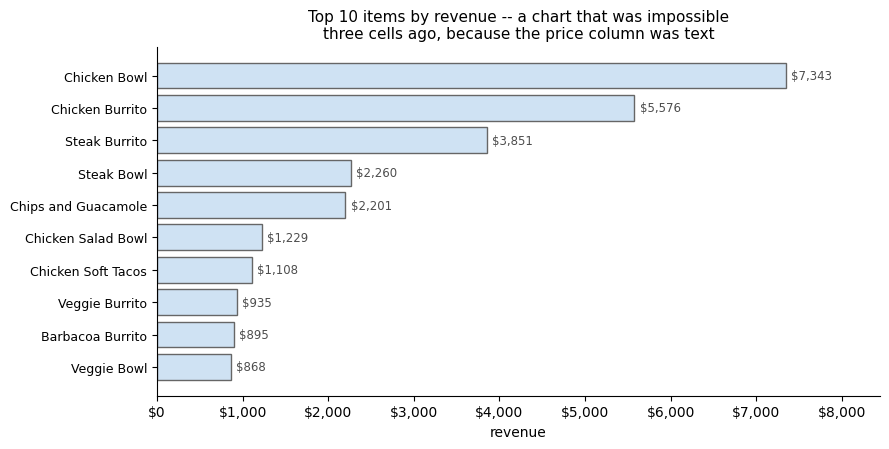

In [ ]:
import matplotlib.pyplot as plt

top = by_item.head(10)[::-1]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(range(len(top)), top.values, color='#cfe2f3', edgecolor='0.4')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel('revenue')
ax.set_title('Top 10 items by revenue -- a chart that was impossible\n'
             'three cells ago, because the price column was text', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(lambda x, p: f'${x:,.0f}')
for i, v in enumerate(top.values):
    ax.text(v + 60, i, f'${v:,.0f}', va='center', fontsize=8.5, color='0.3')
ax.set_xlim(0, top.max() * 1.15)
fig.tight_layout()
plt.show()

Chicken Bowl brings in $7,343, more than the next two items combined, and the average order is $18.81. That is something you could hand to a manager.

Getting there took one type conversion. The analysis was never the hard part.

---

## Part 2 — the five fixes, on eight rows

Working data scientists report spending more than half their time on cleaning. Not because it is tedious, but because of what you just saw: **the mess decides what the answer is.**

The Chipotle file had one broken column. Most files have several, and they interact. So here are the five fixes that handle nearly everything, in the order you should do them, on eight rows small enough to check by eye.

Eight rows is the point. At 4,622 you cannot tell whether a fix did what you meant. At eight you can read every value before and after.

In [ ]:
import pandas as pd, numpy as np
from io import StringIO
raw = '''order_id,item,category,qty,price,ts
1,Cheeseburger,Food,2,$7.50,2026-09-05T12:03:00
1,Cheeseburger,Food,2,$7.50,2026-09-05T12:03:00
2,cheese burger,food,1,7.5,09/05/2026 12:40
3,Foam Finger,Merch,NULL,12,2026-09-05 13:00:00
4,UVA T-Shirt ,Apparel,2,$24.00,2026-09-05 13:05
5,Rain Poncho,RainGear,-3,6,2026-09-05T13:20:00
6,rain poncho,rain-gear,4,$6.00,
7,,Merch,1,12,2026-09-05T14:00:00'''
df = pd.read_csv(StringIO(raw))
df

,order_id,item,category,qty,price,ts
0,1,Cheeseburger,Food,2.0,$7.50,2026-09-05T12:03:00
1,1,Cheeseburger,Food,2.0,$7.50,2026-09-05T12:03:00
2,2,cheese burger,food,1.0,7.5,09/05/2026 12:40
3,3,Foam Finger,Merch,NaN,12,2026-09-05 13:00:00
4,4,UVA T-Shirt,Apparel,2.0,$24.00,2026-09-05 13:05
5,5,Rain Poncho,RainGear,-3.0,6,2026-09-05T13:20:00
6,6,rain poncho,rain-gear,4.0,$6.00,NaN
7,7,NaN,Merch,1.0,12,2026-09-05T14:00:00


### Take inventory before you touch anything

Three commands, every time, in this order. They tell you what kind of mess you have before you start guessing.

In [ ]:
print('shape:', df.shape)
print()
print(df.dtypes)
print()
print('nulls per column:')
print(df.isnull().sum())
print()
print('exact duplicate rows:', df.duplicated().sum())

shape: (8, 6)

order_id      int64
item            str
category        str
qty         float64
price           str
ts              str
dtype: object

nulls per column:
order_id    0
item        1
category    0
qty         1
price       0
ts          1
dtype: int64

exact duplicate rows: 1


Read what those are telling you. `qty` and `price` came in as `object`, which means **text** — so the file contains something non-numeric in both columns. There is one null in `item` and one in `ts`. And one row is an exact duplicate of another.

Before the fixes, write down the number you are trying to get right. Otherwise you have no way to tell whether cleaning helped.

In [ ]:
# The question: how much revenue did we take, and how many units moved?
# We cannot even compute it yet -- price is text. That is itself the first finding.
print(df['price'].tolist())
print(df['qty'].tolist())

['$7.50', '$7.50', '7.5', '12', '$24.00', '6', '$6.00', '12']
[2.0, 2.0, 1.0, nan, 2.0, -3.0, 4.0, 1.0]


### Fix 1 — duplicates, and which kind you mean

`drop_duplicates()` removes rows identical across **every** column. That is the safe version and it is what we want here: rows 0 and 1 are the same transaction exported twice.

In [ ]:
clean = df.drop_duplicates().copy()
print('rows:', len(df), '->', len(clean))

rows: 8 -> 7


Be careful with the other kind. `drop_duplicates(subset=['order_id'])` keeps one row per order id — which is right if ids should be unique, and destroys your data if an order can legitimately have several line items. Look before you choose.

In [ ]:
# Here, order_id 1 appeared twice because of the double export -- already handled.
# But note what subset= would do if orders had multiple items each:
print('unique order_ids:', clean['order_id'].nunique(), 'of', len(clean), 'rows')

unique order_ids: 7 of 7 rows


### Fix 2 — numbers that arrived as text

`price` has dollar signs. Strip them and convert. Real files also bring commas (`'1,240.00'`) and parentheses for negatives (`'(45.00)'`), so build the habit of stripping everything that is not part of a number.

In [ ]:
clean['price'] = (clean['price'].astype(str)
                  .str.replace('$', '', regex=False)
                  .str.replace(',', '', regex=False)
                  .str.strip()
                  .astype(float))
print(clean['price'].dtype)
clean[['order_id', 'item', 'price']]

float64


,order_id,item,price
0,1,Cheeseburger,7.5
2,2,cheese burger,7.5
3,3,Foam Finger,12.0
4,4,UVA T-Shirt,24.0
5,5,Rain Poncho,6.0
6,6,rain poncho,6.0
7,7,NaN,12.0


### Fix 3 — coercion, and the decision it forces

`qty` contains the string `'NULL'`. `astype(int)` would just crash. `pd.to_numeric` with `errors='coerce'` turns anything unparseable into `NaN` — which does not solve the problem, it *surfaces* it. Now you have to decide what a missing quantity means.

In [ ]:
clean['qty'] = pd.to_numeric(clean['qty'], errors='coerce')
print(clean[['order_id', 'item', 'qty']])
print()
print('missing qty:', clean['qty'].isna().sum())
print('negative qty:', (clean['qty'] < 0).sum())

   order_id           item  qty
0         1   Cheeseburger  2.0
2         2  cheese burger  1.0
3         3    Foam Finger  NaN
4         4   UVA T-Shirt   2.0
5         5    Rain Poncho -3.0
6         6    rain poncho  4.0
7         7            NaN  1.0

missing qty: 1
negative qty: 1


Two separate problems, two separate decisions:

**Missing quantity.** Dropping the row loses a real sale. Filling with 1 invents data. Filling with the median invents data and hides it. Here, dropping is defensible because one row of eight is a small, reportable loss — but you report it.

**Negative quantity.** A `-3` is almost certainly a refund. Whether it belongs in your total depends on the question: gross units sold excludes it, net revenue includes it. State which one you are computing.

The rule for the whole course: **record the decision, and record how many rows it touched.** A cleaning step with no row count is not reviewable.

In [ ]:
before = len(clean)
dropped_missing = clean['qty'].isna().sum()
dropped_negative = (clean['qty'] < 0).sum()

clean = clean[clean['qty'].notna() & (clean['qty'] > 0)].copy()
clean['qty'] = clean['qty'].astype(int)

print(f'dropped {dropped_missing} row(s) with no quantity')
print(f'dropped {dropped_negative} refund row(s) -- computing GROSS units')
print(f'rows: {before} -> {len(clean)}')

dropped 1 row(s) with no quantity
dropped 1 refund row(s) -- computing GROSS units
rows: 7 -> 5


### Fix 4 — text that means the same thing

`Food` and `food`. `RainGear` and `rain-gear`. `Apparel` that is really merch. To a computer these are four or five distinct categories, so every group-by is fragmented and every chart has duplicate bars.

Lowercase and strip first, then map the remaining variants explicitly.

In [ ]:
print('before:', sorted(clean['category'].unique()))

clean['category'] = (clean['category'].str.strip().str.lower()
                     .str.replace('-', '', regex=False))
print('after normalizing case and punctuation:', sorted(clean['category'].unique()))

before: ['Apparel', 'Food', 'Merch', 'food', 'rain-gear']
after normalizing case and punctuation: ['apparel', 'food', 'merch', 'raingear']


Case and punctuation get you most of the way. The rest is a business decision that no amount of string handling can make for you: is `apparel` the same category as `merch`? Somebody has to answer that, and the mapping is where you write the answer down.

In [ ]:
CATEGORY_MAP = {
    'apparel': 'merch',      # decision: apparel rolls up into merch
    'raingear': 'raingear',
}
clean['category'] = clean['category'].replace(CATEGORY_MAP)
print('final categories:', sorted(clean['category'].unique()))
print()
print(clean['category'].value_counts())

final categories: ['food', 'merch', 'raingear']

category
food        2
merch       2
raingear    1
Name: count, dtype: int64


Do the same for `item`, where the same product is written two ways.

In [ ]:
print('before:', sorted(clean['item'].dropna().unique()))

clean['item'] = clean['item'].str.strip().str.title()
ITEM_MAP = {'Cheese Burger': 'Cheeseburger'}
clean['item'] = clean['item'].replace(ITEM_MAP)
print('after: ', sorted(clean['item'].dropna().unique()))

before: ['Cheeseburger', 'UVA T-Shirt ', 'cheese burger', 'rain poncho']
after:  ['Cheeseburger', 'Rain Poncho', 'Uva T-Shirt']


### Fix 5 — dates in four formats

This column has ISO timestamps, a US-style `09/05/2026 12:40`, a date with no seconds, and one empty cell. `pd.to_datetime` with `format='mixed'` handles the variety, and `errors='coerce'` turns the unparseable ones into `NaT` instead of raising.

In [ ]:
clean['ts'] = pd.to_datetime(clean['ts'], errors='coerce', format='mixed')
print(clean['ts'].dtype)
print('unparseable timestamps (NaT):', clean['ts'].isna().sum())
clean[['order_id', 'item', 'ts']]

datetime64[us]
unparseable timestamps (NaT): 1


,order_id,item,ts
0,1,Cheeseburger,2026-09-05 12:03:00
2,2,Cheeseburger,2026-09-05 12:40:00
4,4,Uva T-Shirt,2026-09-05 13:05:00
6,6,Rain Poncho,NaT
7,7,NaN,2026-09-05 14:00:00


A real datetime column is what makes the next month of this course possible: you cannot group by hour, join to daily weather, or plot a time series against a text column.

The `NaT` row is a decision again. Keep it if you only need totals; drop it if you are doing anything time-based, because a row with no timestamp cannot be placed on a timeline.

In [ ]:
clean['hour'] = clean['ts'].dt.hour
clean[['order_id', 'item', 'ts', 'hour']]

,order_id,item,ts,hour
0,1,Cheeseburger,2026-09-05 12:03:00,12.0
2,2,Cheeseburger,2026-09-05 12:40:00,12.0
4,4,Uva T-Shirt,2026-09-05 13:05:00,13.0
6,6,Rain Poncho,NaT,NaN
7,7,NaN,2026-09-05 14:00:00,14.0


### Prove it, then measure what changed

State what must now be true. If an assertion fails, you learn it here instead of in a chart three cells later.

In [ ]:
assert clean.duplicated().sum() == 0, 'duplicates remain'
assert clean['price'].dtype == float, 'price is not numeric'
assert clean['qty'].min() >= 1, 'non-positive quantities remain'
assert pd.api.types.is_datetime64_any_dtype(clean['ts']), 'ts is not a datetime'
assert clean['category'].str.islower().all(), 'inconsistent category text'
print('clean:', clean.shape)

clean: (5, 7)


Now the part that justifies the whole session. Compute the answer the naive way and the clean way, and look at the gap.

In [ ]:
clean['revenue'] = clean['qty'] * clean['price']

naive_rows = len(df)
naive_units = pd.to_numeric(df['qty'], errors='coerce').fillna(0).sum()
naive_categories = df['category'].nunique()

print(f'rows:        {naive_rows} raw -> {len(clean)} clean')
print(f'units:       {naive_units:.0f} raw -> {clean["qty"].sum()} clean')
print(f'categories:  {naive_categories} raw -> {clean["category"].nunique()} clean')
print(f'revenue:     ${clean["revenue"].sum():.2f} (not computable before cleaning)')

rows:        8 raw -> 5 clean
units:       9 raw -> 10 clean
categories:  6 raw -> 3 clean
revenue:     $106.50 (not computable before cleaning)


Six apparent categories collapse to three. That is the difference between a chart with six confusing bars and one a manager can read.

### The order matters

This sequence is not arbitrary — each step depends on the last:

1. **Duplicates first.** Cheaper to fix five rows than to fix six and then delete one.
2. **Types next.** You cannot filter on `qty > 0` while `qty` is text.
3. **Then missing and out-of-range values**, now that comparisons work.
4. **Then text normalization**, so each group collects every row that belongs to it.
5. **Then dates**, so anything time-based becomes possible.
6. **Then assert**, so the next person can trust it.

---

## Part 3 — finish the real file

Back to the Chipotle orders. Run the checklist against it and see which fixes apply.

Fix 2 is already done — we converted the price in Part 1. There are no bad quantities, so Fix 3 has nothing to do, and the file has no date column at all, so Fix 5 sits this one out. That leaves two: the duplicate decision from Fix 1, and the text cleanup from Fix 4.

Running the checklist and skipping what does not apply is the normal outcome. Few files need all five.

**The duplicate decision.** Those 59 identical rows could be double-scans or two people ordering the same thing. We will treat them as double-scans and remove them, because an identical row down to the toppings and the timestamp-free ordering is more likely a system artifact than a coincidence. You could argue the other way. What you cannot do is decide silently, so the cell prints the count.

**The text cleanup.** Three menu items are spelled two ways, differing only by a hyphen: `Chips and Tomatillo-Red Chili Salsa` and `Chips and Tomatillo Red Chili Salsa` are the same chips. Separately, `Canned Soda` and `Canned Soft Drink` look like the same product under two names, which is a judgment call rather than a spelling problem, so it goes in a map where somebody can see it and argue.

In [ ]:
food = orders.drop_duplicates().copy()
print(f'exact duplicate rows removed: {len(orders) - len(food)} ({len(orders):,} -> {len(food):,})')

before_items = food['item_name'].nunique()
food['item_name'] = (food['item_name']
                     .str.replace('-', ' ', regex=False)
                     .str.replace(r'\s+', ' ', regex=True)
                     .str.strip())

NAME_MAP = {'Canned Soda': 'Canned Soft Drink'}   # decision: same product
food['item_name'] = food['item_name'].replace(NAME_MAP)
print(f'menu items: {before_items} -> {food["item_name"].nunique()}')

exact duplicate rows removed: 59 (4,622 -> 4,563)
menu items: 50 -> 46


In [ ]:
assert food['price'].dtype == float, 'price is not numeric'
assert food['price'].notna().all(), 'a price failed to convert'
assert (food['quantity'] > 0).all(), 'non-positive quantity'
assert food.duplicated().sum() == 0, 'duplicates remain'

print('rows   :', f'{len(orders):,} raw -> {len(food):,} clean')
print('items  :', orders['item_name'].nunique(), 'raw ->', food['item_name'].nunique(), 'clean')
print(f"revenue: ${orders['price'].sum():,.2f} raw -> ${food['price'].sum():,.2f} clean")

print()
print('Where combining the spellings actually mattered:')
a = orders.groupby('item_name')['price'].sum().sort_values(ascending=False)
b = food.groupby('item_name')['price'].sum().sort_values(ascending=False)
for name in ['Canned Soft Drink', 'Chips and Tomatillo Green Chili Salsa',
             'Chips and Roasted Chili Corn Salsa']:
    ra, rb = list(a.index).index(name) + 1, list(b.index).index(name) + 1
    print(f'  {name:40s} ${a[name]:7.2f} (#{ra}) -> ${b[name]:7.2f} (#{rb})')

rows   : 4,622 raw -> 4,563 clean
items  : 50 raw -> 46 clean
revenue: $34,500.16 raw -> $34,177.25 clean

Where combining the spellings actually mattered:
  Canned Soft Drink                        $ 438.75 (#17) -> $ 560.16 (#14)
  Chips and Tomatillo Green Chili Salsa    $ 132.75 (#29) -> $ 211.62 (#25)
  Chips and Roasted Chili Corn Salsa       $  67.85 (#37) -> $ 110.87 (#30)


$34,177.25 instead of $34,500.16. Dropping 59 rows moved the total by $322.91, about one percent. The menu went from 50 items to 46.

Nothing dramatic happened at the top — Chicken Bowl led before and after. Further down it mattered more. Combining the two names for canned soda moved it from 17th to 14th, and the roasted chili corn salsa chips jumped seven places.

Sometimes cleaning rewrites your headline number. Sometimes it shuffles a few rows in the middle and leaves the story alone. You do not get to know which until you look, and **"I checked, and it barely moved" is a real result** worth putting in your writeup.

The four `assert` lines are the habit worth stealing. They cost one cell, and they turn "I think it is clean" into something the notebook re-checks every time it runs.

---

## Clean once, save it, never clean it again

That took real work. Do not redo it every time your runtime restarts, and on Colab it will restart. Anything you write to `/content` is deleted when the session ends. Your notebook survives because it lives in Drive. Your data files do not, unless you put them there too.

So connect Drive, name one folder, and build every path from it.

In [ ]:
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')       # asks you to authorize, once per session
    DATA_DIR = Path('/content/drive/MyDrive/DS2002/data')
else:
    # Not on Colab: a scratch folder that does NOT survive. Same variable
    # name, so nothing below has to care where it is writing.
    import tempfile
    DATA_DIR = Path(tempfile.gettempdir()) / 'ds2002-data'

DATA_DIR.mkdir(parents=True, exist_ok=True)

out = DATA_DIR / 'chipotle_clean.csv'
food.to_csv(out, index=False)

assert out.exists(), f'save failed: {out}'
print('saved to :', out)
print('size     :', f'{out.stat().st_size:,} bytes')

# Read it back. 'I thought it saved' is not a recoverable position.
check = pd.read_csv(out)
print('rows back:', f'{len(check):,}')

saved to : /var/folders/h4/4rnnhgr11s3b_06kp9v6l7rm0000gn/T/ds2002-data/chipotle_clean.csv
size     : 386,259 bytes
rows back: 4,563


The first time you run that, Colab opens a window asking you to sign in and allow access to your Drive. Pick the Google account that owns your course folder. You re-authorize once per session, every session. That is normal and there is no way around it.

Three habits in that cell worth keeping:

- **`DATA_DIR` is defined once.** Every path after it is `DATA_DIR / 'something.csv'`, so moving the folder later is a one-line change instead of a search-and-replace.
- **`mkdir(parents=True, exist_ok=True)` before writing.** `to_csv` will not create a missing folder for you, and `exist_ok=True` means re-running the cell is safe.
- **Read it back and check.** "I thought it saved" is not a recoverable position at 11pm the night before something is due.

Next session you skip all of Part 1 and Part 3: `pd.read_csv(DATA_DIR / 'chipotle_clean.csv')` and you are working in one line.

For the rest of it — uploading files from your laptop, downloading results, zipping a folder, timestamped saves so you never overwrite good output — see **`notebooks/10-Reference/Colab File Persistence and Google Drive — Reference.ipynb`**. It is a reference, not a class day, so read it when you need it.

Wednesday you run this whole sequence yourself, and Friday you run it on a file where you cannot eyeball the answer.

### Practice 1 — revenue by category

Using `clean`, print revenue per category, highest first. Which category would you tell the vendor to stock more of?

In [ ]:
# TODO

### Practice 2 — the refund question

We dropped the refund row and called the result gross units. Recompute **net** units and net revenue with the refund included, starting again from `df`. How much does the answer move, and which number would you put in front of a manager?

In [ ]:
# TODO: start from df, repeat the cleaning, but keep negative quantities

**Which number, and why:** _..._